# **Symptom Network Constructed Using Graphical LASSO.**

**Imports**

In [ ]:

import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import GraphicalLassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
    matthews_corrcoef
)



**Dataset Loading**

In [ ]:
df = pd.read_csv("/content/Processed.csv")
data = df.copy()
data.columns = [c.strip() for c in data.columns]

print("Dataset shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())


Dataset shape: (2028, 39)

Columns:
['Age', 'Gender', 'University', 'Department', 'Academic_Year', 'Current_CGPA', 'waiver_or_scholarship', 'PSS1', 'PSS2', 'PSS3', 'PSS4', 'PSS5', 'PSS6', 'PSS7', 'PSS8', 'PSS9', 'PSS10', 'Stress Value', 'Stress Label', 'GAD1', 'GAD2', 'GAD3', 'GAD4', 'GAD5', 'GAD6', 'GAD7', 'Anxiety Value', 'Anxiety Label', 'PHQ1', 'PHQ2', 'PHQ3', 'PHQ4', 'PHQ5', 'PHQ6', 'PHQ7', 'PHQ8', 'PHQ9', 'Depression Value', 'Depression Label']


**Column definitions**

In [ ]:

# Reduced symptom set
symptom_cols = [
    'PSS1', 'PSS2', 'PSS3', 'PSS4', 'PSS5', 'PSS6', 'PSS7', 'PSS8', 'PSS9', 'PSS10',
    'GAD1', 'GAD2', 'GAD3', 'GAD4', 'GAD5', 'GAD6', 'GAD7',
    'PHQ1', 'PHQ2', 'PHQ3', 'PHQ4', 'PHQ5', 'PHQ6', 'PHQ7', 'PHQ8', 'PHQ9'
]

stress_cols = ['PSS1', 'PSS2', 'PSS3', 'PSS4', 'PSS5', 'PSS6', 'PSS7', 'PSS8', 'PSS9', 'PSS10']
anxiety_cols = ['GAD1', 'GAD2', 'GAD3', 'GAD4', 'GAD5', 'GAD6', 'GAD7']
depression_cols = ['PHQ1', 'PHQ2', 'PHQ3', 'PHQ4', 'PHQ5', 'PHQ6', 'PHQ7', 'PHQ8', 'PHQ9']

drop_leakage_cols = [
    'Stress Value',
    'Anxiety Value',
    'Depression Value'
]

target_cols = [
    'Stress Label',
    'Anxiety Label',
    'Depression Label'
]

required_cols = symptom_cols + target_cols + drop_leakage_cols
missing_cols = [c for c in required_cols if c not in data.columns]

if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")
else:
    print("All required columns are present.")


All required columns are present.


**Label Encoding and Classification**

In [ ]:

# Remove leakage columns
data = data.drop(columns=drop_leakage_cols)
print("Shape after dropping leakage columns:", data.shape)


# 6. Clean target text

def clean_text(x):
    if pd.isna(x):
        return np.nan
    return str(x).strip()

for col in target_cols:
    data[col] = data[col].apply(clean_text)

def map_anxiety_label(x):
    x = str(x).strip().lower()
    if x == 'minimal anxiety':
        return 0
    elif x == 'mild anxiety':
        return 1
    elif x == 'moderate anxiety':
        return 2
    elif x == 'severe anxiety':
        return 3
    return np.nan

def map_stress_label(x):
    x = str(x).strip().lower()
    if x == 'low stress':
        return 0
    elif x == 'moderate stress':
        return 1
    elif x == 'high perceived stress':
        return 2
    return np.nan


def map_depression_label(x):
    x = str(x).strip().lower()
    if x in ['no depression', 'minimal depression']:
        return 0
    elif x == 'mild depression':
        return 1
    elif x == 'moderate depression':
        return 2
    elif x in ['moderately severe depression', 'severe depression']:
        return 3
    return np.nan

data['Stress_Target'] = data['Stress Label'].apply(map_stress_label)
data['Anxiety_Target'] = data['Anxiety Label'].apply(map_anxiety_label)
data['Depression_Target'] = data['Depression Label'].apply(map_depression_label)

data = data.dropna(subset=['Anxiety_Target', 'Depression_Target']).reset_index(drop=True)

data['Stress_Target'] = data['Stress_Target'].astype(int)
data['Anxiety_Target'] = data['Anxiety_Target'].astype(int)
data['Depression_Target'] = data['Depression_Target'].astype(int)

num_stress_classes = 3
num_anxiety_classes = 4
num_depression_classes = 4

print(data[['Stress Label', 'Stress_Target']].drop_duplicates().sort_values('Stress_Target'))
print(data[['Anxiety Label', 'Anxiety_Target']].drop_duplicates().sort_values('Anxiety_Target'))
print(data[['Depression Label', 'Depression_Target']].drop_duplicates().sort_values('Depression_Target'))


# print(data[['Stress Label', 'Stress_Target']].drop_duplicates().sort_values('Stress_Target'))
# print(data[['Anxiety Label', 'Anxiety_Target']].drop_duplicates().sort_values('Anxiety_Target'))
# print(data[['Depression Label', 'Depression_Target']].drop_duplicates().sort_values('Depression_Target'))


Shape after dropping leakage columns: (2028, 36)
            Stress Label  Stress_Target
7             Low Stress              0
1        Moderate Stress              1
0  High Perceived Stress              2
      Anxiety Label  Anxiety_Target
2   Minimal Anxiety               0
5      Mild Anxiety               1
1  Moderate Anxiety               2
0    Severe Anxiety               3
                Depression Label  Depression_Target
2                  No Depression                  0
6             Minimal Depression                  0
10               Mild Depression                  1
3            Moderate Depression                  2
0              Severe Depression                  3
1   Moderately Severe Depression                  3


**Prepare symptom matrix**

In [ ]:

X_symptom = data[symptom_cols].copy()

symptom_imputer = SimpleImputer(strategy='median')
X_symptom_imputed = symptom_imputer.fit_transform(X_symptom)

symptom_scaler = StandardScaler()
X_symptom_scaled = symptom_scaler.fit_transform(X_symptom_imputed)

print("Symptom matrix shape:", X_symptom_scaled.shape)
print("First 3 rows after scaling:\n", X_symptom_scaled[:3])


Symptom matrix shape: (2028, 26)
First 3 rows after scaling:
 [[ 0.5513849   1.4467218   0.25785107 -0.30213417 -0.15962365 -0.71998272
   0.06626399  0.24565727  1.33715904  1.34106426  0.23307104  0.35613152
   1.25059497  0.22530815  0.13658529  0.20419359  0.25288159  0.56135718
   0.19782292  1.26306926  0.04402909  0.47697301  0.1948299   0.3501842
   1.52066023  0.72135678]
 [ 0.5513849   0.58201452  1.14116521 -0.30213417  0.76264634  0.19031962
   0.06626399  0.24565727 -0.36193778  0.48366252 -0.81730244  0.35613152
   0.24655435 -0.8108028  -0.88177858  1.21174735  0.25288159  1.60771045
   0.19782292  0.31856172  0.04402909  0.47697301  0.1948299   0.3501842
   0.54659234  0.72135678]
 [-1.99385466 -2.01210733 -2.39209134 -1.93825728 -2.00416364 -0.71998272
  -1.89553692 -1.5209844  -2.06103461 -2.08854271 -1.86767591 -1.5905928
  -1.76152688 -1.84691375 -1.90014246 -1.81091394 -1.6395312  -1.53134936
  -1.73559819 -1.57045337 -2.00863745 -1.43847503 -1.66892028 -1.59816577

**Construct symptom graph using Graphical LASSO**

In [ ]:

glasso = GraphicalLassoCV()
glasso.fit(X_symptom_scaled)

precision_matrix = glasso.precision_

def precision_to_partial_corr(precision):
    d = np.sqrt(np.diag(precision))
    partial_corr = -precision / np.outer(d, d)
    np.fill_diagonal(partial_corr, 0.0)
    return partial_corr

partial_corr_matrix = precision_to_partial_corr(precision_matrix)

threshold = 0.05
adj_matrix = partial_corr_matrix.copy()
adj_matrix[np.abs(adj_matrix) < threshold] = 0.0

src, dst = np.nonzero(adj_matrix)
edge_index = torch.tensor(np.vstack((src, dst)), dtype=torch.long)
edge_weight = torch.tensor(adj_matrix[src, dst], dtype=torch.float)

print("Number of nodes:", len(symptom_cols))
print("Number of edges:", edge_index.shape[1])



Number of nodes: 26
Number of edges: 144


**Visualize symptom graph with groups and edge weights**

Number of nodes: 26
Number of edges: 72


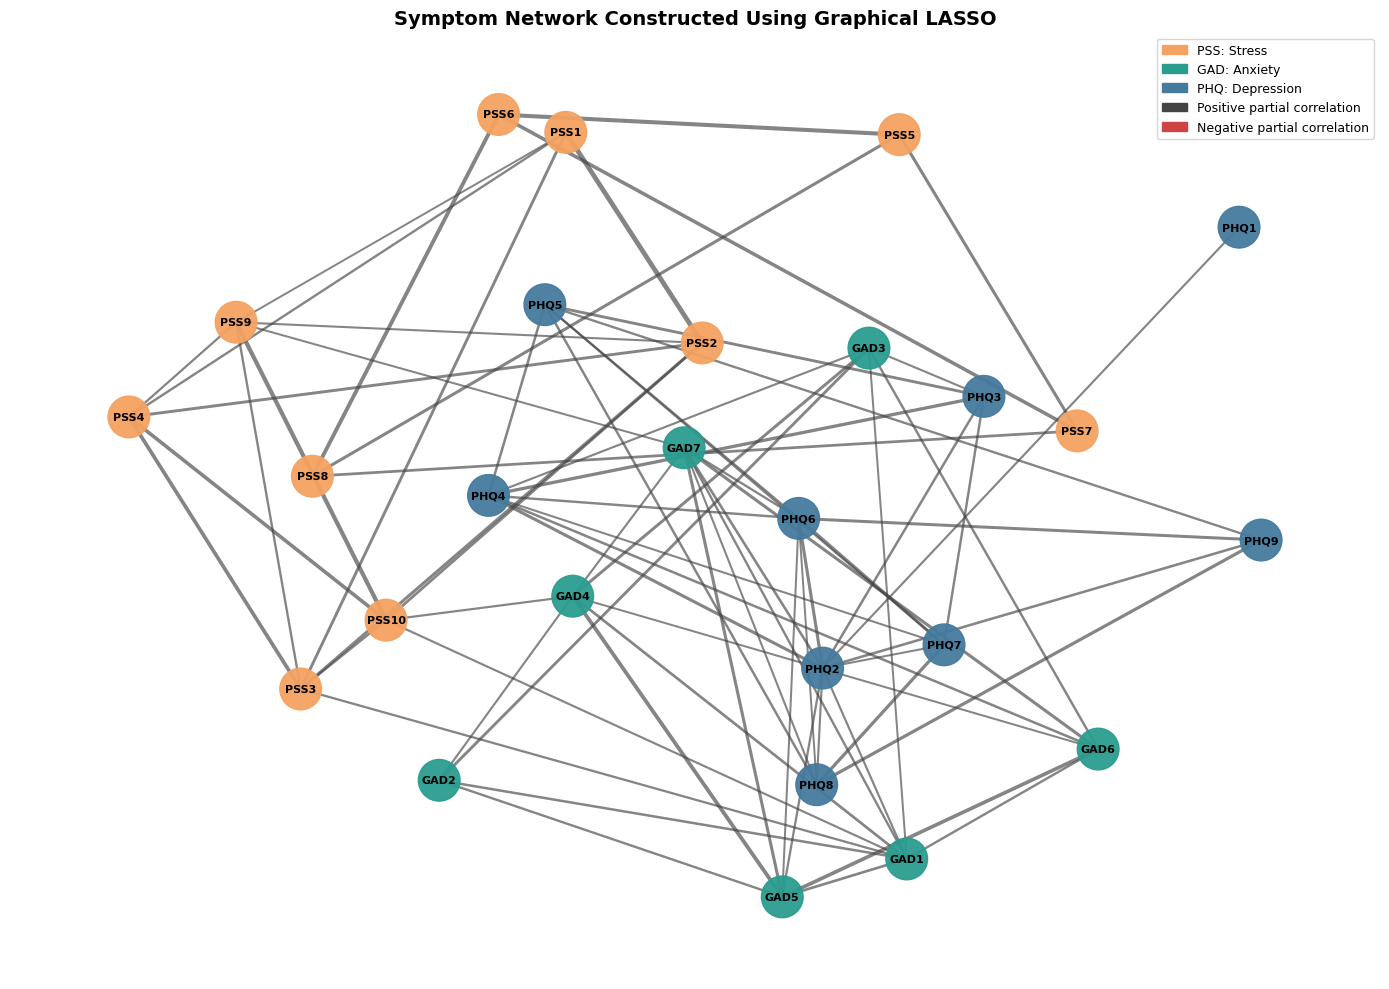

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Build undirected graph from adjacency matrix
G = nx.Graph()

# Add all symptom nodes, including isolated nodes
for col in symptom_cols:
    G.add_node(col)

# Add only upper-triangle edges to avoid duplicates
for i in range(len(symptom_cols)):
    for j in range(i + 1, len(symptom_cols)):
        weight = adj_matrix[i, j]
        if weight != 0:
            G.add_edge(
                symptom_cols[i],
                symptom_cols[j],
                weight=weight,
                abs_weight=abs(weight)
            )

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

# Node colors by questionnaire group
node_colors = []
for node in G.nodes():
    if node.startswith("PSS"):
        node_colors.append("#F4A261")  # Stress
    elif node.startswith("GAD"):
        node_colors.append("#2A9D8F")  # Anxiety
    elif node.startswith("PHQ"):
        node_colors.append("#457B9D")  # Depression
    else:
        node_colors.append("#CCCCCC")

# Edge widths by absolute partial correlation
edge_widths = [
    1 + 8 * G[u][v]["abs_weight"]
    for u, v in G.edges()
]

# Edge styles/colors: positive vs negative partial correlation
edge_colors = [
    "#444444" if G[u][v]["weight"] > 0 else "#CC4444"
    for u, v in G.edges()
]

plt.figure(figsize=(14, 10))

pos = nx.spring_layout(
    G,
    seed=42,
    k=0.8
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=900,
    alpha=0.95
)

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    edge_color=edge_colors,
    alpha=0.65
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=8,
    font_weight="bold"
)

# Manual legend
import matplotlib.patches as mpatches

legend_items = [
    mpatches.Patch(color="#F4A261", label="PSS: Stress"),
    mpatches.Patch(color="#2A9D8F", label="GAD: Anxiety"),
    mpatches.Patch(color="#457B9D", label="PHQ: Depression"),
    mpatches.Patch(color="#444444", label="Positive partial correlation"),
    mpatches.Patch(color="#CC4444", label="Negative partial correlation")
]

plt.legend(
    handles=legend_items,
    loc="best",
    fontsize=9,
    frameon=True
)

plt.title(
    "Symptom Network Constructed Using Graphical LASSO",
    fontsize=14,
    fontweight="bold"
)

plt.axis("off")
plt.tight_layout()
plt.show()

**Visualize symptom graph with proper figure size**

Number of nodes: 26
Number of edges: 72


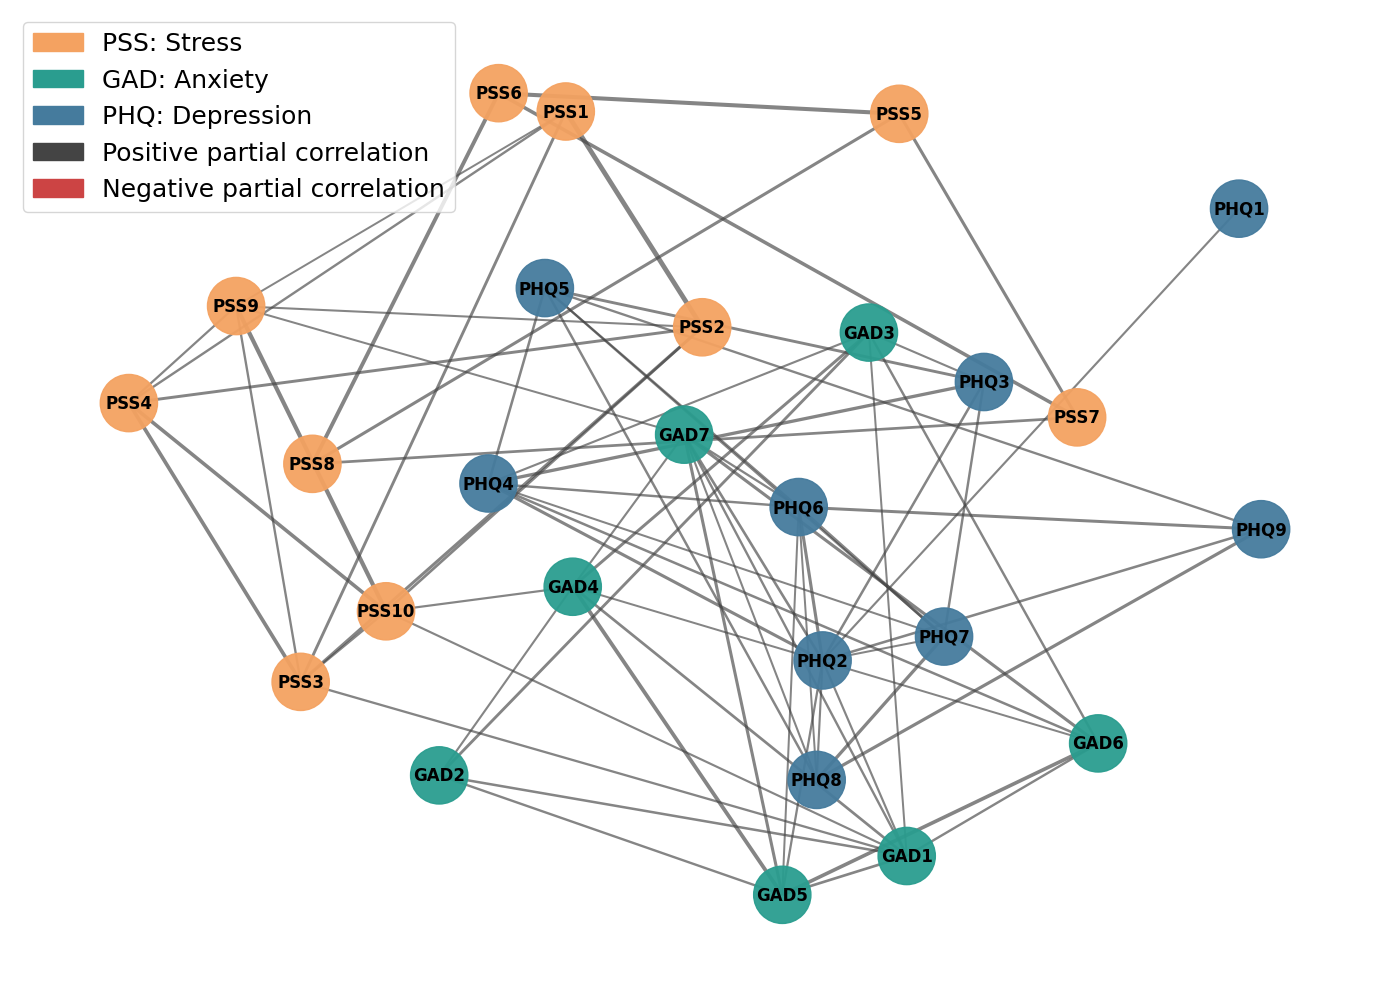

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Build undirected graph from adjacency matrix
G = nx.Graph()

# Add all symptom nodes, including isolated nodes
for col in symptom_cols:
    G.add_node(col)

# Add only upper-triangle edges to avoid duplicates
for i in range(len(symptom_cols)):
    for j in range(i + 1, len(symptom_cols)):
        weight = adj_matrix[i, j]
        if weight != 0:
            G.add_edge(
                symptom_cols[i],
                symptom_cols[j],
                weight=weight,
                abs_weight=abs(weight)
            )

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

# Node colors by questionnaire group
node_colors = []
for node in G.nodes():
    if node.startswith("PSS"):
        node_colors.append("#F4A261")  # Stress
    elif node.startswith("GAD"):
        node_colors.append("#2A9D8F")  # Anxiety
    elif node.startswith("PHQ"):
        node_colors.append("#457B9D")  # Depression
    else:
        node_colors.append("#CCCCCC")

# Edge widths by absolute partial correlation
edge_widths = [
    1 + 8 * G[u][v]["abs_weight"]
    for u, v in G.edges()
]

# Edge styles/colors: positive vs negative partial correlation
edge_colors = [
    "#444444" if G[u][v]["weight"] > 0 else "#CC4444"
    for u, v in G.edges()
]

plt.figure(figsize=(14, 10))

pos = nx.spring_layout(
    G,
    seed=42,
    k=0.8
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=1700,
    alpha=.95
)

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    edge_color=edge_colors,
    alpha=0.65
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=12,
    font_weight="bold"
)

# Manual legend
import matplotlib.patches as mpatches

legend_items = [
    mpatches.Patch(color="#F4A261", label="PSS: Stress"),
    mpatches.Patch(color="#2A9D8F", label="GAD: Anxiety"),
    mpatches.Patch(color="#457B9D", label="PHQ: Depression"),
    mpatches.Patch(color="#444444", label="Positive partial correlation"),
    mpatches.Patch(color="#CC4444", label="Negative partial correlation")
]

plt.legend(
    handles=legend_items,
    loc="best",
    fontsize=18,
    frameon=True
)

# plt.title(
#     "Symptom Network Constructed Using Graphical LASSO",
#     fontsize=14,
#     fontweight="bold"
# )

plt.axis("off")
plt.tight_layout()
plt.show()